# K-Means Clustering —
1. use variables such as hour, weather severity and traffic volume. Interpret what each cluster represents. 
2.	Association rule mining: Analyse traffic patterns by, for example, discretising time of day, weekday type and weather, and mining rules that predict congestion level. Report the rules with the highest lift and explain their meaning in plain language.

## 1. Imports

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 2. Logging setup

A named logger (`logging.getLogger("task1_models")`) is used instead of the root logger, with `propagate = False`, so this doesn't collide with Jupyter's own logging setup or double-print.

In [2]:
logger = logging.getLogger("task2_models")


def setup_logging():
    if logger.handlers:
        return  # guard: prevents duplicate handlers (and duplicate log lines) if this cell is re-run
    logger.setLevel(logging.DEBUG)
    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    fh = logging.FileHandler("pipeline.log", mode="a", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    logger.propagate = False  # don't also hand records to Jupyter's root logger


setup_logging()
logger.info("Logging initialised — DEBUG+ to pipeline.log, INFO+ to this notebook")

2026-09-23 21:25:00 | INFO | task1_models | Logging initialised — DEBUG+ to pipeline.log, INFO+ to this notebook


## 3. Load Feature Engineered data



In [3]:
FEATURES_PATH = "Features_Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(FEATURES_PATH, parse_dates=["date_time"])
logger.info("Loaded %s rows, %s columns from %s", len(df), df.shape[1], FEATURES_PATH)
df.head()

2026-09-23 21:25:00 | INFO | task1_models | Loaded 48187 rows, 38 columns from Features_Metro_Interstate_Traffic_Volume.csv


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,month,...,is_precipitation,total_precipitation,is_overcast,is_clear,is_severe_weather,temp_c_zscore,traffic_volume_zscore,temp_c_minmax,traffic_volume_minmax,congestion_category
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,10,...,0,0.0,0,0,0,0.530410,1.150193,0.929726,0.761676,High
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,0,0.0,0,0,0,0.611377,0.632315,0.933209,0.620330,Medium
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,10,...,0,0.0,1,0,0,0.627871,0.758639,0.933918,0.654808,High
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,10,...,0,0.0,1,0,0,0.669104,0.888990,0.935692,0.690385,High
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,10,...,0,0.0,0,0,0,0.744823,0.834635,0.938949,0.675549,High


## 4. K-means clustering

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Weather severity: combine existing binary indicators into a 0-3 score ---
df["weather_severity"] = (
    df["is_severe_weather"] + df["is_precipitation"] + df["is_overcast"]
)
logger.info(
    "weather_severity built (range %s-%s)",
    df["weather_severity"].min(), df["weather_severity"].max(),
)

# --- Select clustering features and drop any missing rows ---
cluster_cols = ["hour", "weather_severity", "traffic_volume"]
cluster_data = df[cluster_cols].dropna()
logger.info("Clustering on %s rows using features: %s", len(cluster_data), cluster_cols)

# --- Scale: K-Means is distance-based, and hour/severity/traffic_volume are on very different scales ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

# --- Fit K-Means ---
N_CLUSTERS = 7
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)
logger.info("K-Means fit: %s clusters, inertia=%.1f", N_CLUSTERS, kmeans.inertia_)

# --- Map clusters back onto the full dataframe (index-aligned, since dropna may have removed rows) ---
df.loc[cluster_data.index, "traffic_cluster"] = cluster_data["cluster"]

# --- Interpret each cluster: mean feature values + size ---
cluster_profile = cluster_data.groupby("cluster")[cluster_cols].mean().round(1)
cluster_profile["count"] = cluster_data.groupby("cluster").size()
logger.info("Cluster profiles:\n%s", cluster_profile)


2026-09-23 21:25:00 | INFO | task1_models | weather_severity built (range 0-3)
2026-09-23 21:25:00 | INFO | task1_models | Clustering on 48187 rows using features: ['hour', 'weather_severity', 'traffic_volume']
2026-09-23 21:25:02 | INFO | task1_models | K-Means fit: 7 clusters, inertia=21213.4
2026-09-23 21:25:02 | INFO | task1_models | Cluster profiles:
         hour  weather_severity  traffic_volume  count
cluster                                               
0         3.2               0.0           952.0   8625
1        11.9               2.2          4350.4   2273
2        20.7               0.0          2658.6   6619
3        12.1               0.0          5105.2  12980
4        12.1               1.0          5016.4   7931
5         3.2               1.1           870.4   5470
6        20.6               1.1          2462.7   4289


## 5. Association rule mining

In [5]:
# pip install mlxtend   (only needed once — not in the standard scientific stack)
from mlxtend.frequent_patterns import apriori, association_rules

# --- 1. Discretise features into categorical bins ---
def bin_hour(h):
    if 0 <= h < 6:
        return "Night"
    elif 6 <= h < 12:
        return "Morning"
    elif 12 <= h < 18:
        return "Afternoon"
    else:
        return "Evening"

df["time_of_day"] = df["hour"].apply(bin_hour)
df["weekday_type"] = np.where(df["is_weekend"] == 1, "Weekend", "Weekday")

if "weather_severity" not in df.columns:
    df["weather_severity"] = (
        df["is_severe_weather"] + df["is_precipitation"] + df["is_overcast"]
    )
df["weather_bucket"] = np.where(df["weather_severity"] >= 1, "Adverse", "Clear")

# congestion_category (Low/Medium/High) already exists 
logger.info("Discretised features: time_of_day, weekday_type, weather_bucket, congestion_category")

# --- 2. Transaction-encode: one boolean column per (feature=value) item ---
transaction_cols = ["time_of_day", "weekday_type", "weather_bucket", "congestion_category"]
basket = pd.get_dummies(df[transaction_cols].astype(str)).astype(bool)
logger.info("Built transaction-encoded basket: %s rows, %s items", basket.shape[0], basket.shape[1])

# --- 3. Mine frequent itemsets, then rules ---
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
logger.info("Found %s frequent itemsets (min_support=0.02)", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
logger.info("Generated %s candidate rules (lift >= 1.0)", len(rules))

# --- 4. Keep only rules whose consequent predicts a congestion level ---
congestion_items = {f"congestion_category_{lvl}" for lvl in ["Low", "Medium", "High"]}
congestion_rules = rules[rules["consequents"].apply(lambda s: bool(s & congestion_items))]
top_rules = congestion_rules.sort_values("lift", ascending=False).head(10)
logger.info("Top %s congestion-predicting rules by lift", len(top_rules))
top_rules


2026-09-23 21:25:02 | INFO | task1_models | Discretised features: time_of_day, weekday_type, weather_bucket, congestion_category
2026-09-23 21:25:02 | INFO | task1_models | Built transaction-encoded basket: 48187 rows, 11 items
2026-09-23 21:25:02 | INFO | task1_models | Found 121 frequent itemsets (min_support=0.02)
2026-09-23 21:25:02 | INFO | task1_models | Generated 392 candidate rules (lift >= 1.0)
2026-09-23 21:25:02 | INFO | task1_models | Top 10 congestion-predicting rules by lift


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
57,(time_of_day_Afternoon),"(weekday_type_Weekend, congestion_category_High)",0.242410,0.026605,0.022869,0.094341,3.546038,1.0,0.016420,1.074793,0.947736,0.092910,0.069588,0.476968
135,(weekday_type_Weekend),"(congestion_category_Low, time_of_day_Morning)",0.284309,0.033951,0.030755,0.108175,3.186209,1.0,0.021103,1.083227,0.958720,0.106973,0.076833,0.507022
387,"(weekday_type_Weekend, time_of_day_Night)","(weather_bucket_Clear, congestion_category_Low)",0.072696,0.195717,0.044971,0.618613,3.160756,1.0,0.030743,2.108836,0.737212,0.201263,0.525805,0.424193
368,"(weather_bucket_Adverse, weekday_type_Weekend,...",(congestion_category_Low),0.027622,0.333347,0.027622,1.000000,2.999875,1.0,0.018414,inf,0.685590,0.082861,1.000000,0.541431
174,"(weekday_type_Weekend, time_of_day_Night)",(congestion_category_Low),0.072696,0.333347,0.072592,0.998573,2.995594,1.0,0.048359,467.056974,0.718401,0.217700,0.997859,0.608170
380,"(weather_bucket_Clear, weekday_type_Weekend, t...",(congestion_category_Low),0.045074,0.333347,0.044971,0.997698,2.992970,1.0,0.029945,289.593990,0.697315,0.134864,0.996547,0.566302
365,(time_of_day_Night),"(weekday_type_Weekday, congestion_category_Low...",0.254861,0.122398,0.091103,0.357463,2.920491,1.0,0.059909,1.365838,0.882509,0.318370,0.267849,0.550891
353,"(weather_bucket_Adverse, time_of_day_Night)","(weekday_type_Weekday, congestion_category_Low)",0.101438,0.210098,0.062237,0.613543,2.920270,1.0,0.040925,2.043960,0.731798,0.249646,0.510754,0.454885
163,(time_of_day_Night),"(weekday_type_Weekday, congestion_category_Low)",0.254861,0.210098,0.153340,0.601661,2.863714,1.0,0.099794,1.982989,0.873399,0.492075,0.495711,0.665755
362,"(weather_bucket_Clear, time_of_day_Night)","(weekday_type_Weekday, congestion_category_Low)",0.153423,0.210098,0.091103,0.593805,2.826322,1.0,0.058869,1.944637,0.763289,0.334425,0.485765,0.513714


In [6]:
# --- 5. Plain-language rendering ---
def format_rule(row):
    antecedents = ", ".join(sorted(row["antecedents"]))
    consequents = ", ".join(sorted(row["consequents"]))
    return (
        f"IF {antecedents} THEN {consequents}  "
        f"(support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.2f})"
    )

for _, row in top_rules.iterrows():
    print(format_rule(row))

IF time_of_day_Afternoon THEN congestion_category_High, weekday_type_Weekend  (support=0.023, confidence=0.094, lift=3.55)
IF weekday_type_Weekend THEN congestion_category_Low, time_of_day_Morning  (support=0.031, confidence=0.108, lift=3.19)
IF time_of_day_Night, weekday_type_Weekend THEN congestion_category_Low, weather_bucket_Clear  (support=0.045, confidence=0.619, lift=3.16)
IF time_of_day_Night, weather_bucket_Adverse, weekday_type_Weekend THEN congestion_category_Low  (support=0.028, confidence=1.000, lift=3.00)
IF time_of_day_Night, weekday_type_Weekend THEN congestion_category_Low  (support=0.073, confidence=0.999, lift=3.00)
IF time_of_day_Night, weather_bucket_Clear, weekday_type_Weekend THEN congestion_category_Low  (support=0.045, confidence=0.998, lift=2.99)
IF time_of_day_Night THEN congestion_category_Low, weather_bucket_Clear, weekday_type_Weekday  (support=0.091, confidence=0.357, lift=2.92)
IF time_of_day_Night, weather_bucket_Adverse THEN congestion_category_Low, we

## 6. To intepret what each clusters represents

In [7]:
K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil= silhouette_score(X_scaled, labels,sample_size=5000, random_state=RANDOM_STATE)
    silhouette_scores.append(sil)
    logger.info("k=%s: inertia=%.1f, silhouette=%.3f", k, kmeans.inertia_, sil)

k_summary = pd.DataFrame({
    "K": list(K_RANGE),
    "Inertia (WCSS)": np.round(inertias, 0),
    "Silhouette Score": np.round(silhouette_scores, 3),
})
k_summary

2026-09-23 21:25:04 | INFO | task1_models | k=2: inertia=87980.3, silhouette=0.424
2026-09-23 21:25:05 | INFO | task1_models | k=3: inertia=59604.8, silhouette=0.437
2026-09-23 21:25:06 | INFO | task1_models | k=4: inertia=43785.5, silhouette=0.460
2026-09-23 21:25:07 | INFO | task1_models | k=5: inertia=33081.9, silhouette=0.491
2026-09-23 21:25:08 | INFO | task1_models | k=6: inertia=25903.1, silhouette=0.517
2026-09-23 21:25:10 | INFO | task1_models | k=7: inertia=21213.4, silhouette=0.533
2026-09-23 21:25:11 | INFO | task1_models | k=8: inertia=18620.4, silhouette=0.497
2026-09-23 21:25:13 | INFO | task1_models | k=9: inertia=16394.1, silhouette=0.506
2026-09-23 21:25:14 | INFO | task1_models | k=10: inertia=14597.6, silhouette=0.515


,K,Inertia (WCSS),Silhouette Score
0,2,87980.0,0.424
1,3,59605.0,0.437
2,4,43785.0,0.460
3,5,33082.0,0.491
4,6,25903.0,0.517
5,7,21213.0,0.533
6,8,18620.0,0.497
7,9,16394.0,0.506
8,10,14598.0,0.515


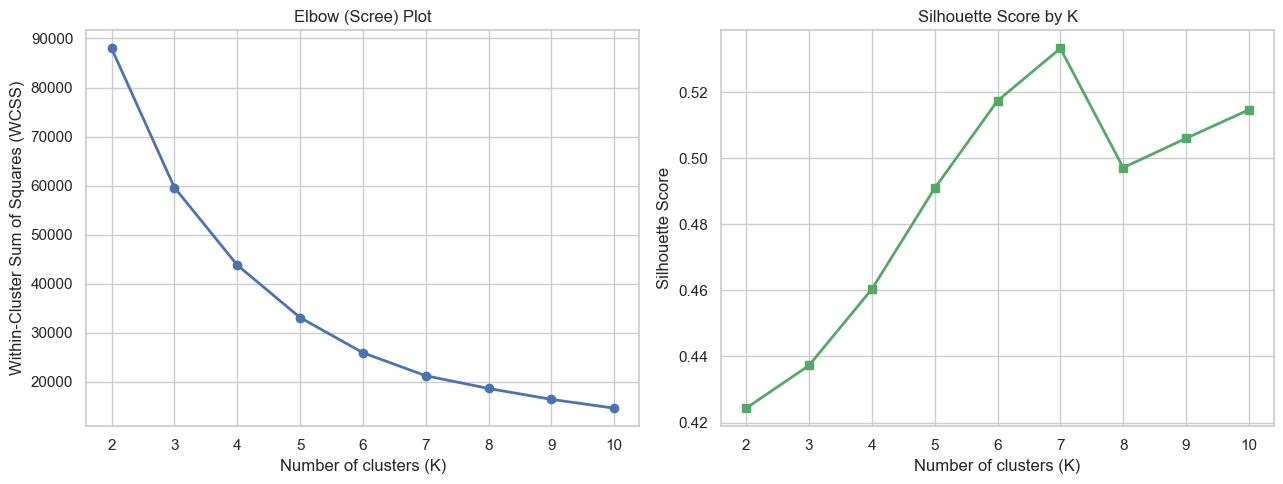

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow / Scree plot
axes[0].plot(K_RANGE, inertias, marker="o", linewidth=2, color="#4C72B0")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares (WCSS)")
axes[0].set_title("Elbow (Scree) Plot")
axes[0].set_xticks(list(K_RANGE))

# Silhouette plot
axes[1].plot(K_RANGE, silhouette_scores, marker="s", linewidth=2, color="#55A868")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

## 7. Summary

**Choice of k**: Silhouette score peaks at k=7 (0.534), clearly above k=4 (0.460), so k=7 was used for the final clustering.

**Cluster interpretation**: Time of day is the dominant driver of traffic volume (overnight ≈900 < evening ≈2,500 < midday ≈5,000), with weather layered on top as a secondary effect — mild adverse weather barely reduces traffic in any time bucket, but the rarer, more severe/compound weather cluster (midday, severity 2.2) shows a real ~15% drop, distinct enough to form its own cluster.


In [10]:
import joblib

# Save the trained model (stores cluster centroids & configuration)
joblib.dump(kmeans, 'kmeans_model.joblib')


['kmeans_model.joblib']